# task 2 -> unsupervised domain adaptation on pacs

## imports

In [1]:
# !pip install -q pyarrow

In [2]:
from pathlib import Path
import copy
import io
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


SEED = 6304 #fixed by the assignment, covers every random draw
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device {device}')
if torch.cuda.is_available():
    print(f'gpu {torch.cuda.get_device_name(0)}  '
          f'memory {torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:.0f} gb  '
          f'capability {".".join(str(v) for v in torch.cuda.get_device_capability(0))}')
print(f'torch {torch.__version__}  cuda {torch.version.cuda}  cudnn {torch.backends.cudnn.version()}')

DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./outputs/task2_uda')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
SHARED_DIR = Path('../shared') #shared w task 3, same splits and erm checkpoint
for directory in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR, SHARED_DIR / 'checkpoints']:
    directory.mkdir(parents=True, exist_ok=True)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device cuda
gpu NVIDIA RTX PRO 6000 Blackwell Server Edition  memory 95 gb  capability 12.0
torch 2.11.0+cu128  cuda 12.8  cudnn 91900


## global env variables ->

In [3]:
CLASS_NAMES = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
NUM_CLASSES = 7
FEATURE_DIMENSION = 512 #feature right before the head, every alignment loss acts here

SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
TARGET_DOMAIN = 'sketch'

#pinned to a commit cuz the split file stores row indices into it
PACS_URL = ('https://huggingface.co/datasets/flwrlabs/pacs/resolve/'
            '394113073258ead631f617d2e13bb377c0715c4b/data/train-00000-of-00001.parquet')

RESIZE_SIZE = 256
CROP_SIZE = 224

SOURCE_BATCH_PER_DOMAIN = 8
TARGET_BATCH = 24
SOURCE_BATCH = SOURCE_BATCH_PER_DOMAIN * len(SOURCE_DOMAINS) #24
EVAL_BATCH_SIZE = 128
NUM_WORKERS_PER_LOADER = 2 #jpeg decoding bound, ask for ~8 cpus

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
PATIENCE = 5

MMD_WEIGHT = 1.0
MMD_BANDWIDTH_FACTORS = [0.5, 1.0, 2.0] #multiples of the median pairwise sq distance
DISCRIMINATOR_HIDDEN = 256
DISCRIMINATOR_DROPOUT = 0.5
GRL_MAX_COEFFICIENT = 1.0
DOMAIN_LOSS_WEIGHT = 1.0

#deviation -> grad clip at norm 1.0 caps the adversarial feedback loop, same in every run
GRADIENT_CLIP_NORM = 1.0

DESIGN_STUDY_MMD_WEIGHTS = [0.1, 1.0, 10.0] #lambda_mmd sweep lines up w task 3

#deviation -> 0.1 arm is a multiplier on the domain loss itself, not the grl coefficient
DESIGN_STUDY_DOMAIN_WEIGHTS = [0.1, 1.0]

SEPARABILITY_TEST_FRACTION = 0.3
SEPARABILITY_C = 1.0

SPLIT_PATH = SHARED_DIR / 'pacs_splits_seed6304.json'
ERM_CHECKPOINT_PATH = SHARED_DIR / 'checkpoints' / 'source_only_erm.pt'
ERM_HISTORY_PATH = SHARED_DIR / 'source_only_erm_history.csv'

## pacs loading and the shared source splits

In [4]:
pacs_path = DATA_DIR / 'pacs.parquet'
if not pacs_path.exists():
    torch.hub.download_url_to_file(PACS_URL, pacs_path)

pacs_frame = pd.read_parquet(pacs_path)

image_bytes = [entry['bytes'] for entry in pacs_frame['image']] #kept compressed, decoded per item, decoding all 9991 upfront eats gbs of ram
domains_all = pacs_frame['domain'].to_numpy()
labels_all = pacs_frame['label'].to_numpy()
del pacs_frame

display(pd.crosstab(pd.Series(domains_all, name='domain'), pd.Series([CLASS_NAMES[label] for label in labels_all], name='class')))

class,dog,elephant,giraffe,guitar,horse,house,person
domain,,,,,,,
art_painting,379,255,285,184,201,295,449
cartoon,389,457,346,135,324,288,405
photo,189,202,182,186,199,280,432
sketch,772,740,753,608,816,80,160


In [5]:
#stratified 80/20 per source domain, split on row indices not images
splits = {}
for domain in SOURCE_DOMAINS:
    domain_rows = np.flatnonzero(domains_all == domain)
    train_rows, val_rows = train_test_split(
        domain_rows, test_size=0.2, stratify=labels_all[domain_rows], random_state=SEED
    )
    splits[domain] = {'train': sorted(train_rows.tolist()), 'val': sorted(val_rows.tolist())}

target_rows = np.flatnonzero(domains_all == TARGET_DOMAIN) #unlabelled adaptation set

split_record = { #holds no sketch info, task 3 isnt allowed any
    'seed': SEED,
    'pacs_url': PACS_URL,
    'source_domains': SOURCE_DOMAINS,
    'target_domain': TARGET_DOMAIN,
    'class_names': CLASS_NAMES,
    'splits': splits,
}
SPLIT_PATH.write_text(json.dumps(split_record, indent=1))

for domain in SOURCE_DOMAINS:
    print(f"{domain:13s} train {len(splits[domain]['train']):5d}  val {len(splits[domain]['val']):4d}")
print(f'{TARGET_DOMAIN:13s} unlabelled adaptation set {len(target_rows)}')

photo         train  1336  val  334
art_painting  train  1638  val  410
cartoon       train  1875  val  469
sketch        unlabelled adaptation set 3929


## transforms, datasets and loaders

In [6]:
pretrained_preset = ResNet18_Weights.IMAGENET1K_V1.transforms() #normalisation from the weights preset
NORMALIZATION_MEAN = pretrained_preset.mean
NORMALIZATION_STD = pretrained_preset.std

train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])


class PACSImages(Dataset):
    def __init__(self, rows, transform, labels=None): #labels=None -> images only, no loop can read a target label
        self.rows = np.asarray(rows)
        self.transform = transform
        self.labels = labels

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, position):
        row = self.rows[position]
        image = self.transform(Image.open(io.BytesIO(image_bytes[row])).convert('RGB'))
        if self.labels is None:
            return image
        return image, int(self.labels[row])


def make_training_loaders():
    #fresh seeded generators every run -> identical source batches + augs across methods
    source_loaders = {}
    for domain_index, domain in enumerate(SOURCE_DOMAINS):
        source_loaders[domain] = DataLoader(
            PACSImages(splits[domain]['train'], train_transform, labels_all),
            batch_size=SOURCE_BATCH_PER_DOMAIN, shuffle=True,
            drop_last=True, #exactly 8 per domain every step
            num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available(),
            persistent_workers=True,
            generator=torch.Generator().manual_seed(SEED + domain_index),
        )

    target_loader = DataLoader( #separate generator so target draws never shift the source sequence
        PACSImages(target_rows, train_transform, labels=None), #no labels by construction
        batch_size=TARGET_BATCH, shuffle=True, drop_last=True,
        num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available(),
        persistent_workers=True, generator=torch.Generator().manual_seed(SEED + 100),
    )
    return source_loaders, target_loader


def cycle_forever(loader):
    while True:
        for batch in loader:
            yield batch


source_val_loaders = {
    domain: DataLoader(PACSImages(splits[domain]['val'], eval_transform, labels_all), batch_size=EVAL_BATCH_SIZE,
                       shuffle=False, num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available())
    for domain in SOURCE_DOMAINS
}

total_source_train = sum(len(splits[domain]['train']) for domain in SOURCE_DOMAINS)
STEPS_PER_EPOCH = math.ceil(total_source_train / SOURCE_BATCH)
TOTAL_STEPS = MAX_EPOCHS * STEPS_PER_EPOCH #grl schedule measures progress against the full budget
print(f'pooled source train {total_source_train}  steps per epoch {STEPS_PER_EPOCH}  total step budget {TOTAL_STEPS}')

pooled source train 4849  steps per epoch 203  total step budget 6090


## model, discriminator and the batchnorm policy

In [7]:
class PACSClassifier(nn.Module):
    #split so the 512 feature is reachable, task 3 defines the same class so state dict keys match
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Identity() #drops imagenet head -> pooled 512 feature
        self.classifier = nn.Linear(FEATURE_DIMENSION, NUM_CLASSES)

    def forward(self, images):
        features = self.backbone(images) #(n, 512)
        return features, self.classifier(features)


def build_discriminator(input_dimension):
    return nn.Sequential(
        nn.Linear(input_dimension, DISCRIMINATOR_HIDDEN),
        nn.ReLU(),
        nn.Dropout(DISCRIMINATOR_DROPOUT),
        nn.Linear(DISCRIMINATOR_HIDDEN, 2),
    )


def freeze_batchnorm_statistics(model):
    #frozen bn -> only bn modules in eval (stats stay imagenet, gamma/beta train), call after every model.train()
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


def build_run_modules(method):
    torch.manual_seed(SEED) #same head and disc init for every method
    model = PACSClassifier().to(device)

    discriminator = None
    if method in ('dann', 'cdan'):
        input_dimension = FEATURE_DIMENSION if method == 'dann' else FEATURE_DIMENSION * NUM_CLASSES
        torch.manual_seed(SEED)
        discriminator = build_discriminator(input_dimension).to(device)
    return model, discriminator

## alignment losses

In [8]:
class GradientReversal(torch.autograd.Function):
    #identity forward, flipped + scaled grad backward. used by dann and cdan
    @staticmethod
    def forward(context, inputs, coefficient):
        context.coefficient = coefficient
        return inputs.view_as(inputs) #new tensor so autograd attaches this function

    @staticmethod
    def backward(context, gradient_output):
        return -context.coefficient * gradient_output, None


def grl_coefficient(progress):
    return 2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0


def pairwise_squared_distances(features):
    #expanded form not cdist cuz the sqrt grad is undefined at zero distance
    squared_norms = features.pow(2).sum(dim=1, keepdim=True) #(n, 1)
    return (squared_norms + squared_norms.T - 2 * features @ features.T).clamp_min(0) #(n, n)


def multi_kernel_mmd(source_features, target_features, bandwidth_factors=MMD_BANDWIDTH_FACTORS):
    combined = torch.cat([source_features, target_features])
    squared_distances = pairwise_squared_distances(combined)

    #bandwidth from the median off diagonal distance, detached so the backbone cant game it
    number_of_points = combined.size(0)
    off_diagonal = ~torch.eye(number_of_points, dtype=torch.bool, device=combined.device)
    median_distance = squared_distances[off_diagonal].detach().median().clamp_min(1e-8)

    kernel = sum(torch.exp(-squared_distances / (factor * median_distance)) for factor in bandwidth_factors)

    #deviation -> unbiased estimator, self pairs dropped since k(x,x)=3 would inflate the within set terms
    number_of_source = source_features.size(0)
    number_of_target = combined.size(0) - number_of_source

    within_source = kernel[:number_of_source, :number_of_source]
    within_target = kernel[number_of_source:, number_of_source:]
    source_source = (within_source.sum() - within_source.diagonal().sum()) / (number_of_source * (number_of_source - 1))
    target_target = (within_target.sum() - within_target.diagonal().sum()) / (number_of_target * (number_of_target - 1))
    source_target = kernel[:number_of_source, number_of_source:].mean()

    return source_source + target_target - 2 * source_target #unbiased, can dip slightly below 0 (expected)


def domain_adversarial_loss(discriminator, discriminator_input, coefficient, number_of_source):
    reversed_input = GradientReversal.apply(discriminator_input, coefficient)
    domain_logits = discriminator(reversed_input)

    domain_labels = torch.cat([ #source 0, target 1, domain ids only
        torch.zeros(number_of_source, dtype=torch.long, device=domain_logits.device),
        torch.ones(domain_logits.size(0) - number_of_source, dtype=torch.long, device=domain_logits.device),
    ])
    loss = F.cross_entropy(domain_logits, domain_labels)
    accuracy = (domain_logits.argmax(dim=1) == domain_labels).float().mean().item()
    return loss, accuracy, domain_logits.detach().abs().max().item() #runaway disc shows here first

## evaluation helpers

In [9]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_labels, all_predictions, all_features = [], [], []
    for images, labels in loader:
        features, logits = model(images.to(device, non_blocking=True))
        all_labels.append(labels)
        all_predictions.append(logits.argmax(dim=1).cpu())
        all_features.append(features.cpu())
    return torch.cat(all_labels).numpy(), torch.cat(all_predictions).numpy(), torch.cat(all_features).numpy()


def classification_metrics(labels, predictions):
    return {
        'accuracy': 100 * float((labels == predictions).mean()),
        'macro_f1': 100 * f1_score(labels, predictions, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0),
    }


def evaluate_source_validation(model):
    row = {}
    for domain in SOURCE_DOMAINS:
        labels, predictions, _ = predict_loader(model, source_val_loaders[domain])
        metrics = classification_metrics(labels, predictions)
        row[f'{domain}_accuracy'] = metrics['accuracy']
        row[f'{domain}_macro_f1'] = metrics['macro_f1']
    row['mean_source_accuracy'] = float(np.mean([row[f'{domain}_accuracy'] for domain in SOURCE_DOMAINS]))
    row['mean_source_macro_f1'] = float(np.mean([row[f'{domain}_macro_f1'] for domain in SOURCE_DOMAINS]))
    return row

## the shared training loop

In [10]:
def train_run(run_name, method, mmd_weight=MMD_WEIGHT, grl_max=GRL_MAX_COEFFICIENT, domain_weight=DOMAIN_LOSS_WEIGHT):
    model, discriminator = build_run_modules(method)

    parameters = list(model.parameters())
    if discriminator is not None:
        parameters += list(discriminator.parameters())
    optimizer = torch.optim.AdamW(parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    source_loaders, target_loader = make_training_loaders()
    source_iterators = {domain: cycle_forever(loader) for domain, loader in source_loaders.items()}
    target_iterator = cycle_forever(target_loader) if method != 'source_only' else None

    history = []
    best_score = -1.0
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    global_step = 0
    run_start = time.time()

    for epoch in range(MAX_EPOCHS):
        epoch_start = time.time()
        model.train()
        freeze_batchnorm_statistics(model) #must come after train()
        if discriminator is not None:
            discriminator.train()

        classification_loss_sum = 0.0
        alignment_loss_sum = 0.0
        discriminator_accuracy_sum = 0.0
        gradient_norm_sum = 0.0
        gradient_norm_max = 0.0
        clipped_steps = 0
        feature_norm_sum = 0.0
        class_logit_max = 0.0
        domain_logit_max_epoch = 0.0
        backbone_gradient_sum = 0.0
        discriminator_gradient_sum = 0.0
        domain_logit_max = 0.0
        coefficient = 0.0

        for _ in tqdm(range(STEPS_PER_EPOCH), desc=f'{run_name} epoch {epoch + 1}', leave=False):
            source_batches = [next(source_iterators[domain]) for domain in SOURCE_DOMAINS]
            source_images = torch.cat([images for images, _ in source_batches]).to(device, non_blocking=True)
            source_labels = torch.cat([labels for _, labels in source_batches]).to(device, non_blocking=True)
            number_of_source = source_images.size(0)

            if method == 'source_only':
                features, logits = model(source_images)
                classification_loss = F.cross_entropy(logits, source_labels)
                alignment_loss = torch.zeros((), device=device)
                discriminator_accuracy = float('nan')
                total_loss = classification_loss
            else:
                target_images = next(target_iterator).to(device, non_blocking=True) #images only, never labels
                features, logits = model(torch.cat([source_images, target_images])) #joint pass, same as separate ones under frozen bn
                classification_loss = F.cross_entropy(logits[:number_of_source], source_labels)

                if method == 'dan':
                    alignment_loss = multi_kernel_mmd(features[:number_of_source], features[number_of_source:])
                    discriminator_accuracy = float('nan')
                    total_loss = classification_loss + mmd_weight * alignment_loss
                else:
                    coefficient = grl_max * grl_coefficient(global_step / TOTAL_STEPS) #progress vs the full 30 epoch budget
                    #deviation -> disc input l2 normalised (bce unbounded + frozen bn = backbone could inflate the norm), head reads raw
                    normalized_features = F.normalize(features, dim=1)

                    if method == 'dann':
                        discriminator_input = normalized_features
                    else:
                        #cdan -> probs x feature outer product (n, 7, 512) -> 3584, neither f nor p detached
                        probabilities = logits.softmax(dim=1)
                        discriminator_input = torch.bmm(probabilities.unsqueeze(2), normalized_features.unsqueeze(1)).flatten(1)
                    alignment_loss, discriminator_accuracy, domain_logit_max = domain_adversarial_loss(
                        discriminator, discriminator_input, coefficient, number_of_source
                    )
                    total_loss = classification_loss + domain_weight * alignment_loss

            optimizer.zero_grad()
            total_loss.backward()

            backbone_gradient = torch.norm(torch.stack([ #per side norms pre clip, shows which side runs away
                parameter.grad.norm(2) for parameter in model.parameters() if parameter.grad is not None]), 2).item()
            discriminator_gradient = float('nan')
            if discriminator is not None:
                discriminator_gradient = torch.norm(torch.stack([
                    parameter.grad.norm(2) for parameter in discriminator.parameters() if parameter.grad is not None]), 2).item()

            gradient_norm = torch.nn.utils.clip_grad_norm_(parameters, GRADIENT_CLIP_NORM) #returns the pre clip norm
            optimizer.step()
            global_step += 1

            classification_loss_sum += classification_loss.item()
            alignment_loss_sum += alignment_loss.item()
            discriminator_accuracy_sum += discriminator_accuracy
            gradient_norm_sum += gradient_norm.item()
            gradient_norm_max = max(gradient_norm_max, gradient_norm.item())
            clipped_steps += int(gradient_norm.item() > GRADIENT_CLIP_NORM)

            feature_norm_sum += features.detach().norm(dim=1).mean().item() #mean ||f(x)||
            class_logit_max = max(class_logit_max, logits.detach().abs().max().item())
            domain_logit_max_epoch = max(domain_logit_max_epoch, domain_logit_max)
            backbone_gradient_sum += backbone_gradient
            discriminator_gradient_sum += discriminator_gradient if discriminator is not None else 0.0

        batchnorm_gamma_max = max(module.weight.detach().abs().max().item() #only rescaling route under frozen bn
                                  for module in model.modules() if isinstance(module, nn.BatchNorm2d))

        validation = evaluate_source_validation(model) #selection on source val only
        epoch_row = {
            'run': run_name,
            'method': method,
            'epoch': epoch + 1,
            'classification_loss': classification_loss_sum / STEPS_PER_EPOCH,
            'alignment_loss': alignment_loss_sum / STEPS_PER_EPOCH,
            'discriminator_accuracy': 100 * discriminator_accuracy_sum / STEPS_PER_EPOCH,
            'grl_coefficient': coefficient,
            'gradient_norm_mean': gradient_norm_sum / STEPS_PER_EPOCH,
            'gradient_norm_max': gradient_norm_max,
            'clipped_fraction': 100 * clipped_steps / STEPS_PER_EPOCH,
            'feature_norm_mean': feature_norm_sum / STEPS_PER_EPOCH,
            'class_logit_max': class_logit_max,
            'domain_logit_max': domain_logit_max_epoch,
            'backbone_gradient_mean': backbone_gradient_sum / STEPS_PER_EPOCH,
            'discriminator_gradient_mean': discriminator_gradient_sum / STEPS_PER_EPOCH,
            'batchnorm_gamma_max': batchnorm_gamma_max,
            'epoch_seconds': time.time() - epoch_start,
            **validation,
        }
        history.append(epoch_row)

        print(
            f"{run_name} epoch {epoch + 1:02d}/{MAX_EPOCHS} | cls {epoch_row['classification_loss']:.4f} | "
            f"align {epoch_row['alignment_loss']:.4f} | "
            + ' | '.join(f"{domain} f1 {validation[f'{domain}_macro_f1']:.2f}" for domain in SOURCE_DOMAINS)
            + f" | mean f1 {validation['mean_source_macro_f1']:.2f}"
        )

        if validation['mean_source_macro_f1'] > best_score:
            best_score = validation['mean_source_macro_f1']
            best_epoch = epoch + 1
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f'{run_name} stopped early after epoch {epoch + 1}, best epoch {best_epoch}')
                break

    model.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT_DIR / f'{run_name}.pt')

    run_config = {
        'run': run_name, 'method': method, 'mmd_weight': mmd_weight if method == 'dan' else None,
        'grl_max_coefficient': grl_max if method in ('dann', 'cdan') else None,
        'domain_loss_weight': domain_weight if method in ('dann', 'cdan') else None,
        'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'seed': SEED,
        'source_batch_per_domain': SOURCE_BATCH_PER_DOMAIN, 'target_batch': TARGET_BATCH if method != 'source_only' else 0,
        'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'steps_per_epoch': STEPS_PER_EPOCH,
        'epochs_trained': len(history), 'best_epoch': best_epoch, 'best_mean_source_macro_f1': best_score,
        'seconds': time.time() - run_start,
    }

    optimizer.state.clear() #frees adam buffers on gpu
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model.cpu(), pd.DataFrame(history), run_config

## experiment 1 : source only erm

In [11]:
#hypothesis -> sources carry colour + texture sketch lacks so good source val, sharp drop on sketch
models = {}
histories = {}
run_configs = {}

models['source_only'], histories['source_only'], run_configs['source_only'] = train_run('source_only', 'source_only')

torch.save(models['source_only'].state_dict(), ERM_CHECKPOINT_PATH) #task 3 copy of the selected checkpoint
histories['source_only'].to_csv(ERM_HISTORY_PATH, index=False)
print(f'erm checkpoint written to {ERM_CHECKPOINT_PATH}')

display(pd.DataFrame([evaluate_source_validation(models['source_only'].to(device))]).round(2))
models['source_only'] = models['source_only'].cpu()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

 26%|██▌       | 11.6M/44.7M [00:00<00:00, 121MB/s]

 55%|█████▍    | 24.4M/44.7M [00:00<00:00, 126MB/s]

 82%|████████▏ | 36.5M/44.7M [00:00<00:00, 123MB/s]

...

source_only epoch 14:  97%|█████████▋| 196/203 [00:04<00:00, 47.37it/s]

source_only epoch 14:  99%|█████████▉| 201/203 [00:04<00:00, 45.42it/s]

source_only epoch 14/30 | cls 0.0777 | align 0.0000 | photo f1 94.63 | art_painting f1 87.99 | cartoon f1 96.01 | mean f1 92.88
source_only stopped early after epoch 14, best epoch 9


erm checkpoint written to ../shared/checkpoints/source_only_erm.pt


,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1
0,96.11,95.61,90.49,90.45,94.67,95.05,93.76,93.7


## experiment 2 : dan, mmd alignment

In [12]:
#hypothesis -> alignment should close part of the sketch gap but mmd is class blind (sketch dog -> photo horse)
models['dan'], histories['dan'], run_configs['dan'] = train_run('dan', 'dan', mmd_weight=MMD_WEIGHT)

dan epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

dan epoch 1:   0%|          | 1/203 [00:01<05:51,  1.74s/it]

dan epoch 1:   2%|▏         | 4/203 [00:01<01:11,  2.78it/s]

dan epoch 1:   4%|▍         | 8/203 [00:01<00:31,  6.27it/s]

dan epoch 1:   6%|▌         | 12/203 [00:02<00:18, 10.15it/s]

...

dan epoch 11:  93%|█████████▎| 189/203 [00:05<00:00, 34.83it/s]

dan epoch 11:  95%|█████████▌| 193/203 [00:05<00:00, 35.27it/s]

dan epoch 11:  97%|█████████▋| 197/203 [00:05<00:00, 35.53it/s]

dan epoch 11:  99%|█████████▉| 201/203 [00:05<00:00, 36.34it/s]

dan epoch 11/30 | cls 0.0778 | align 0.0099 | photo f1 94.28 | art_painting f1 86.97 | cartoon f1 94.72 | mean f1 91.99
dan stopped early after epoch 11, best epoch 6


## experiment 3 : dann, adversarial alignment

In [13]:
#hypothesis -> learned disc is more flexible than a fixed kernel so stronger confusion than dan, same class mixing risk
models['dann'], histories['dann'], run_configs['dann'] = train_run('dann', 'dann')

dann epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

dann epoch 1:   0%|          | 1/203 [00:01<05:23,  1.60s/it]

dann epoch 1:   2%|▏         | 5/203 [00:01<00:52,  3.77it/s]

dann epoch 1:   5%|▍         | 10/203 [00:01<00:23,  8.31it/s]

dann epoch 1:   7%|▋         | 15/203 [00:01<00:14, 13.05it/s]

...

dann epoch 9:  93%|█████████▎| 189/203 [00:05<00:00, 31.80it/s]

dann epoch 9:  95%|█████████▌| 193/203 [00:05<00:00, 32.76it/s]

dann epoch 9:  97%|█████████▋| 197/203 [00:06<00:00, 31.22it/s]

dann epoch 9:  99%|█████████▉| 201/203 [00:06<00:00, 32.43it/s]

dann epoch 09/30 | cls 0.0908 | align 0.6951 | photo f1 90.05 | art_painting f1 85.07 | cartoon f1 90.67 | mean f1 88.60
dann stopped early after epoch 9, best epoch 4


## experiment 4 : cdan, class conditional adversarial alignment

In [14]:
#hypothesis -> conditioning on predicted probs aligns sketch dogs w source dogs, not the source average
#so more class structure than dann at similar domain confusion
models['cdan'], histories['cdan'], run_configs['cdan'] = train_run('cdan', 'cdan')

cdan epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

cdan epoch 1:   0%|          | 1/203 [00:01<05:26,  1.61s/it]

cdan epoch 1:   2%|▏         | 4/203 [00:01<01:06,  2.98it/s]

cdan epoch 1:   3%|▎         | 7/203 [00:01<00:34,  5.73it/s]

cdan epoch 1:   5%|▌         | 11/203 [00:01<00:19,  9.88it/s]

...

cdan epoch 8:  93%|█████████▎| 189/203 [00:05<00:00, 34.50it/s]

cdan epoch 8:  95%|█████████▌| 193/203 [00:05<00:00, 34.30it/s]

cdan epoch 8:  97%|█████████▋| 197/203 [00:05<00:00, 34.13it/s]

cdan epoch 8:  99%|█████████▉| 201/203 [00:05<00:00, 33.45it/s]

cdan epoch 08/30 | cls 0.1225 | align 0.7253 | photo f1 94.69 | art_painting f1 82.30 | cartoon f1 91.65 | mean f1 89.55
cdan stopped early after epoch 8, best epoch 3


## experiment 6 : design study training, dan at the other two mmd weights

In [15]:
#expectation (trained before the lock) -> separability falls steadily 0.1 to 10, source val holds at 0.1, 1 and slips at 10
#sketch acc peaks in the middle and falls at 10 as heavy alignment merges classes. lambda 1 = the dan run above
domain_weight_runs = {} #dann domain weight arm, 1.0 = existing dann run
for domain_weight in DESIGN_STUDY_DOMAIN_WEIGHTS:
    if domain_weight == DOMAIN_LOSS_WEIGHT:
        domain_weight_runs[domain_weight] = 'dann'
        continue
    run_name = f'dann_domain_{domain_weight:g}'
    models[run_name], histories[run_name], run_configs[run_name] = train_run(
        run_name, 'dann', domain_weight=domain_weight)
    domain_weight_runs[domain_weight] = run_name

design_study_runs = {}
for mmd_weight in DESIGN_STUDY_MMD_WEIGHTS:
    if mmd_weight == MMD_WEIGHT:
        design_study_runs[mmd_weight] = 'dan' #reused, not retrained
        continue
    run_name = f'dan_mmd_{mmd_weight:g}'
    models[run_name], histories[run_name], run_configs[run_name] = train_run(run_name, 'dan', mmd_weight=mmd_weight)
    design_study_runs[mmd_weight] = run_name

dann_domain_0.1 epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

dann_domain_0.1 epoch 1:   0%|          | 1/203 [00:01<04:40,  1.39s/it]

dann_domain_0.1 epoch 1:   2%|▏         | 4/203 [00:01<00:57,  3.44it/s]

dann_domain_0.1 epoch 1:   4%|▍         | 8/203 [00:01<00:25,  7.56it/s]

dann_domain_0.1 epoch 1:   6%|▌         | 12/203 [00:01<00:16, 11.77it/s]

...

dan_mmd_10 epoch 13:  94%|█████████▍| 191/203 [00:05<00:00, 31.75it/s]

dan_mmd_10 epoch 13:  96%|█████████▌| 195/203 [00:06<00:00, 31.95it/s]

dan_mmd_10 epoch 13:  98%|█████████▊| 199/203 [00:06<00:00, 32.66it/s]

dan_mmd_10 epoch 13: 100%|██████████| 203/203 [00:06<00:00, 33.17it/s]

dan_mmd_10 epoch 13/30 | cls 0.3152 | align 0.0148 | photo f1 86.26 | art_painting f1 77.16 | cartoon f1 89.72 | mean f1 84.38
dan_mmd_10 stopped early after epoch 13, best epoch 8


## training curves and saved configurations

,run,method,mmd_weight,epochs_trained,best_epoch,best_mean_source_macro_f1,seconds
0,source_only,source_only,NaN,14,9,93.70,101.25
1,dan,dan,1.0,11,6,92.93,97.05
2,dann,dann,NaN,9,4,92.13,81.67
3,cdan,cdan,NaN,8,3,92.29,74.57
4,dann_domain_0.1,dann,NaN,10,5,93.77,88.04
5,dan_mmd_0.1,dan,0.1,8,3,92.91,76.18
6,dan_mmd_10,dan,10.0,13,8,87.82,116.77


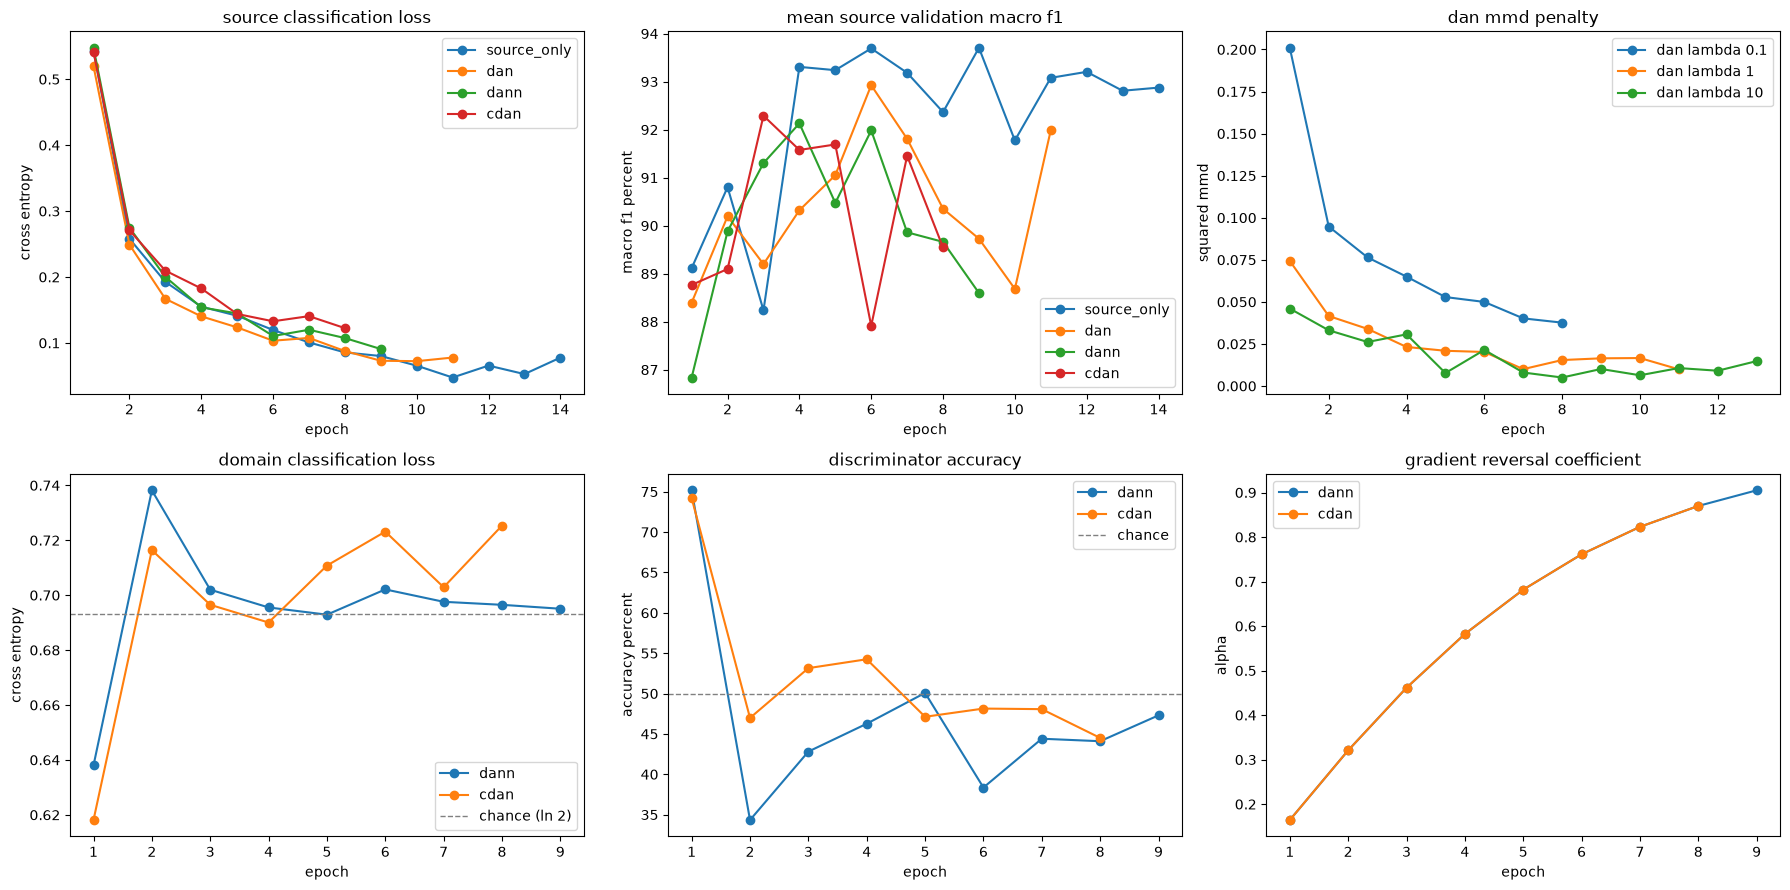

In [16]:
all_history = pd.concat(histories.values(), ignore_index=True)
all_history.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

(OUTPUT_DIR / 'run_configs.json').write_text(json.dumps(run_configs, indent=1))
display(pd.DataFrame(run_configs.values())[['run', 'method', 'mmd_weight', 'epochs_trained', 'best_epoch',
                                           'best_mean_source_macro_f1', 'seconds']].round(2))

main_runs = ['source_only', 'dan', 'dann', 'cdan']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for run_name in main_runs:
    run_history = histories[run_name]
    axes[0, 0].plot(run_history['epoch'], run_history['classification_loss'], marker='o', label=run_name)
    axes[0, 1].plot(run_history['epoch'], run_history['mean_source_macro_f1'], marker='o', label=run_name)

for mmd_weight, run_name in design_study_runs.items():
    axes[0, 2].plot(histories[run_name]['epoch'], histories[run_name]['alignment_loss'], marker='o', label=f'dan lambda {mmd_weight:g}')

for run_name in ['dann', 'cdan']:
    run_history = histories[run_name]
    axes[1, 0].plot(run_history['epoch'], run_history['alignment_loss'], marker='o', label=run_name)
    axes[1, 1].plot(run_history['epoch'], run_history['discriminator_accuracy'], marker='o', label=run_name)
    axes[1, 2].plot(run_history['epoch'], run_history['grl_coefficient'], marker='o', label=run_name)

axes[1, 0].axhline(math.log(2), color='grey', linestyle='--', linewidth=1, label='chance (ln 2)')
axes[1, 1].axhline(50, color='grey', linestyle='--', linewidth=1, label='chance')

panel_labels = [
    (axes[0, 0], 'source classification loss', 'cross entropy'),
    (axes[0, 1], 'mean source validation macro f1', 'macro f1 percent'),
    (axes[0, 2], 'dan mmd penalty', 'squared mmd'),
    (axes[1, 0], 'domain classification loss', 'cross entropy'),
    (axes[1, 1], 'discriminator accuracy', 'accuracy percent'),
    (axes[1, 2], 'gradient reversal coefficient', 'alpha'),
]
for axis, title, y_label in panel_labels:
    axis.set_title(title)
    axis.set_xlabel('epoch')
    axis.set_ylabel(y_label)
    axis.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

## locked evaluation -> every checkpoint and setting above is fixed, target labels are read from here on

In [17]:
#leakage lock -> labelled target loader only built now
target_eval_loader = DataLoader(
    PACSImages(target_rows, eval_transform, labels_all), batch_size=EVAL_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available()
)


def domain_separability(source_features, target_features):
    #domain info left in the features -> 70/30 logreg source vs target, held out acc is the score

    generator = np.random.default_rng(SEED) #recreated per call so every model gets the same target subset
    target_sample = generator.choice(len(target_features), size=len(source_features), replace=False)

    probe_features = np.concatenate([source_features, target_features[target_sample]])
    probe_labels = np.concatenate([np.zeros(len(source_features)), np.ones(len(source_features))]) #domain, not class

    train_features, test_features, train_labels, test_labels = train_test_split(
        probe_features, probe_labels, test_size=SEPARABILITY_TEST_FRACTION, stratify=probe_labels, random_state=SEED
    )
    #deviation -> scaler fitted on the 70% only (inside the pipeline), raw relu ranges are uneven
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=SEPARABILITY_C, class_weight='balanced', max_iter=5000),
    )
    probe.fit(train_features, train_labels)
    return 100 * probe.score(test_features, test_labels)


evaluation = {}
for run_name, model in models.items():
    model = model.to(device)
    source_row = evaluate_source_validation(model)
    source_val_outputs = [predict_loader(model, source_val_loaders[domain]) for domain in SOURCE_DOMAINS]
    source_features = np.concatenate([outputs[2] for outputs in source_val_outputs])
    source_val_labels = np.concatenate([outputs[0] for outputs in source_val_outputs])
    target_labels, target_predictions, target_features = predict_loader(model, target_eval_loader)
    target_metrics = classification_metrics(target_labels, target_predictions)

    evaluation[run_name] = {
        **source_row,
        'target_accuracy': target_metrics['accuracy'],
        'target_macro_f1': target_metrics['macro_f1'],
        'domain_separability': domain_separability(source_features, target_features),
        'target_labels': target_labels,
        'target_predictions': target_predictions,
        'target_features': target_features, #kept so the class probe doesnt rerun backbones
        'source_val_features': source_features,
        'source_val_labels': source_val_labels,
    }
    models[run_name] = model.cpu()
    print(f"{run_name:14s} target acc {target_metrics['accuracy']:.2f}  separability {evaluation[run_name]['domain_separability']:.2f}")

source_only    target acc 65.18  separability 99.86


dan            target acc 56.91  separability 84.34


dann           target acc 31.81  separability 99.86


cdan           target acc 14.58  separability 100.00


dann_domain_0.1 target acc 67.80  separability 99.73


dan_mmd_0.1    target acc 75.49  separability 98.76


dan_mmd_10     target acc 68.44  separability 85.03


,method,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability,target_accuracy_change,domain_gap
0,source_only,96.11,95.61,90.49,90.45,94.67,95.05,93.76,93.70,65.18,64.15,99.86,0.00,28.57
1,dan,95.81,94.94,90.00,89.64,93.82,94.20,93.21,92.93,56.91,55.31,84.34,-8.27,36.30
2,dann,95.21,94.25,86.34,87.21,94.88,94.94,92.14,92.13,31.81,31.52,99.86,-33.37,60.33
3,cdan,95.51,95.17,88.54,88.10,93.39,93.60,92.48,92.29,14.58,24.09,100.00,-50.60,77.89


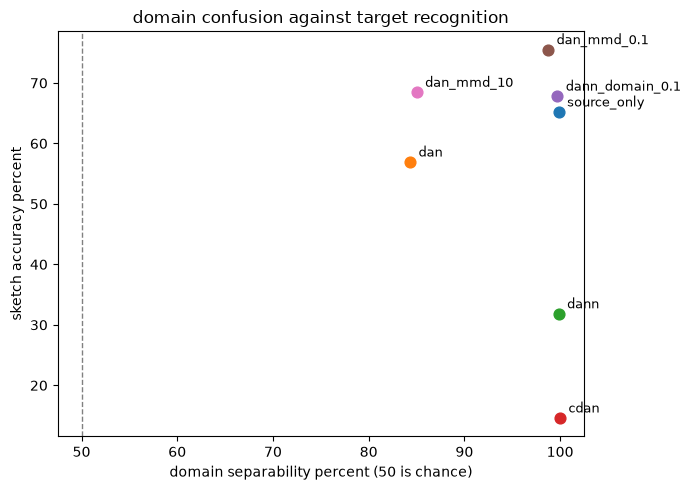

In [18]:
metric_columns = ([f'{domain}_{metric}' for domain in SOURCE_DOMAINS for metric in ('accuracy', 'macro_f1')]
                  + ['mean_source_accuracy', 'mean_source_macro_f1', 'target_accuracy', 'target_macro_f1', 'domain_separability'])

main_results = pd.DataFrame([{'method': run_name, **{column: evaluation[run_name][column] for column in metric_columns}}
                             for run_name in main_runs])
main_results['target_accuracy_change'] = main_results['target_accuracy'] - evaluation['source_only']['target_accuracy']
main_results['domain_gap'] = main_results['mean_source_accuracy'] - main_results['target_accuracy']

main_results.to_csv(OUTPUT_DIR / 'main_results.csv', index=False)
display(main_results.round(2))

fig, axis = plt.subplots(figsize=(7, 5))
for run_name in models:
    axis.scatter(evaluation[run_name]['domain_separability'], evaluation[run_name]['target_accuracy'], s=60)
    axis.annotate(run_name, (evaluation[run_name]['domain_separability'], evaluation[run_name]['target_accuracy']),
                  textcoords='offset points', xytext=(6, 4), fontsize=9)
axis.axvline(50, color='grey', linestyle='--', linewidth=1)
axis.set_xlabel('domain separability percent (50 is chance)')
axis.set_ylabel('sketch accuracy percent')
axis.set_title('domain confusion against target recognition')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'separability_vs_target.png', dpi=180, bbox_inches='tight')
plt.show()

## label shift between the sources and sketch

the size of the prior mismatch marginal alignment is fighting against, computed from class counts alone

In [19]:
#reads sketch class counts (target labels) so it sits after the lock
#perfect alignment matches predicted label mixes -> err_T >= 0.5*sum|p_s(y) - p_t(y)| (zhao et al. 2019)

class_counts = pd.crosstab(pd.Series(domains_all, name='domain'), pd.Series(labels_all, name='label'))
class_counts.columns = [CLASS_NAMES[label] for label in class_counts.columns]

domain_priors = class_counts.div(class_counts.sum(axis=1), axis=0)

source_prior = domain_priors.loc[SOURCE_DOMAINS].mean(axis=0) #mean of per domain priors cuz 8 per domain sampling
target_prior = domain_priors.loc[TARGET_DOMAIN]

total_variation = 0.5 * (source_prior - target_prior).abs().sum()

label_shift = pd.DataFrame({
    'source_share': 100 * source_prior,
    'sketch_share': 100 * target_prior,
    'difference': 100 * (target_prior - source_prior),
    'sketch_images': class_counts.loc[TARGET_DOMAIN],
})
label_shift['under_perfect_alignment'] = np.where(label_shift['difference'] < 0, 'over predicted', 'under predicted')
label_shift = label_shift.sort_values('difference')

class_counts.to_csv(OUTPUT_DIR / 'class_counts_by_domain.csv')
label_shift.to_csv(OUTPUT_DIR / 'label_shift.csv')
(OUTPUT_DIR / 'label_shift_bound.json').write_text(json.dumps({
    'total_variation': float(total_variation),
    'implied_minimum_target_error_percent': float(100 * total_variation),
    'implied_maximum_target_accuracy_percent': float(100 * (1 - total_variation)),
    'source_prior': {name: float(value) for name, value in source_prior.items()},
    'target_prior': {name: float(value) for name, value in target_prior.items()},
    'assumption': 'the bound describes the limit of perfect marginal alignment, it is not a prediction of the error actually measured',
}, indent=1))

display(label_shift.round(2))
print(f'total variation between the source and sketch class priors {total_variation:.4f}')
print(f'perfectly aligned marginals imply at least {100 * total_variation:.1f}% sketch error, '
      f'so at most {100 * (1 - total_variation):.1f}% sketch accuracy')
print(f"source only actually reached {evaluation['source_only']['target_accuracy']:.2f}% on sketch")


,source_share,sketch_share,difference,sketch_images,under_perfect_alignment
person,21.69,4.07,-17.62,160,over predicted
house,14.49,2.04,-12.45,80,over predicted
elephant,14.68,18.83,4.15,740,under predicted
dog,15.47,19.65,4.18,772,under predicted
giraffe,13.19,19.17,5.97,753,under predicted
guitar,8.63,15.47,6.85,608,under predicted
horse,11.85,20.77,8.92,816,under predicted


total variation between the source and sketch class priors 0.3007
perfectly aligned marginals imply at least 30.1% sketch error, so at most 69.9% sketch accuracy
source only actually reached 65.18% on sketch


## class probe -> was it domain information or class information that was removed

the same probe construction as the domain separability score, with the class label in place of the domain label

class probes:   0%|          | 0/7 [00:00<?, ?it/s]

class probes:  14%|█▍        | 1/7 [00:00<00:02,  2.81it/s]

class probes:  29%|██▊       | 2/7 [00:00<00:01,  3.80it/s]

class probes:  43%|████▎     | 3/7 [00:00<00:01,  3.50it/s]

class probes:  57%|█████▋    | 4/7 [00:01<00:00,  3.19it/s]

class probes:  71%|███████▏  | 5/7 [00:01<00:00,  3.45it/s]

class probes:  86%|████████▌ | 6/7 [00:01<00:00,  3.89it/s]

class probes: 100%|██████████| 7/7 [00:02<00:00,  3.30it/s]

class probes: 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]

,method,sketch_class_probe_accuracy,sketch_class_probe_macro_f1,source_class_probe_accuracy,model_target_accuracy,probe_minus_model,domain_separability
0,source_only,88.55,90.02,93.13,65.18,23.37,99.86
1,dan,88.21,90.70,94.51,56.91,31.30,84.34
2,dann,83.46,86.70,93.41,31.81,51.65,99.86
3,cdan,84.56,87.46,94.23,14.58,69.98,100.00
4,dann_domain_0.1,84.56,86.46,94.23,67.80,16.76,99.73
5,dan_mmd_0.1,88.72,90.63,92.03,75.49,13.23,98.76
6,dan_mmd_10,84.31,87.24,89.56,68.44,15.87,85.03


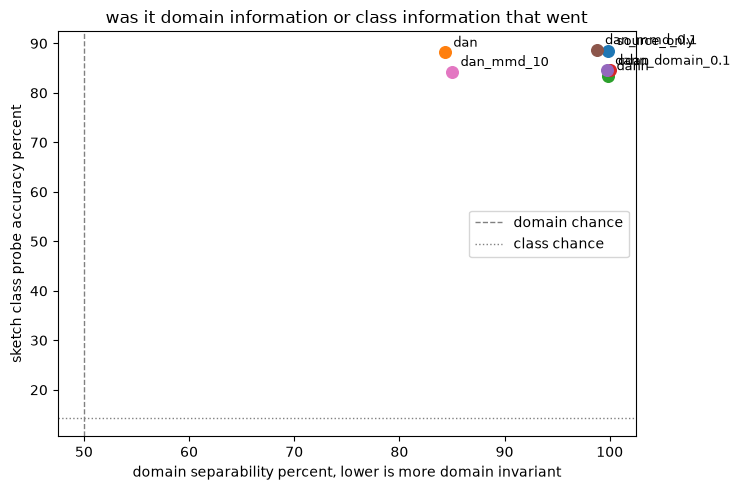

In [20]:
#same construction as the domain probe but predicts class, reads target labels so after the lock
#probe high + model low -> head points the wrong way, probe low -> class structure is gone

def class_probe(features, labels):
    train_features, test_features, train_labels, test_labels = train_test_split( #same split/seed/C/scaler as the domain probe
        features, labels, test_size=SEPARABILITY_TEST_FRACTION, stratify=labels, random_state=SEED
    )
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=SEPARABILITY_C, class_weight='balanced', max_iter=5000), #sketch has 80 to 816 per class
    )
    probe.fit(train_features, train_labels)
    predicted = probe.predict(test_features)
    return {
        'accuracy': 100 * float((predicted == test_labels).mean()),
        'macro_f1': 100 * f1_score(test_labels, predicted, average='macro',
                                   labels=list(range(NUM_CLASSES)), zero_division=0),
    }


probe_rows = []
for run_name in tqdm(evaluation, desc='class probes'):
    target_probe = class_probe(evaluation[run_name]['target_features'], evaluation[run_name]['target_labels'])
    source_probe = class_probe(evaluation[run_name]['source_val_features'], evaluation[run_name]['source_val_labels'])

    probe_rows.append({
        'method': run_name,
        'sketch_class_probe_accuracy': target_probe['accuracy'],
        'sketch_class_probe_macro_f1': target_probe['macro_f1'],
        'source_class_probe_accuracy': source_probe['accuracy'],
        'model_target_accuracy': evaluation[run_name]['target_accuracy'],
        'probe_minus_model': target_probe['accuracy'] - evaluation[run_name]['target_accuracy'],
        'domain_separability': evaluation[run_name]['domain_separability'],
    })

class_probe_results = pd.DataFrame(probe_rows)
class_probe_results.to_csv(OUTPUT_DIR / 'class_probe.csv', index=False)
display(class_probe_results.round(2))

fig, axis = plt.subplots(figsize=(7.5, 5))
for _, row in class_probe_results.iterrows():
    axis.scatter(row['domain_separability'], row['sketch_class_probe_accuracy'], s=70)
    axis.annotate(row['method'], (row['domain_separability'], row['sketch_class_probe_accuracy']),
                  textcoords='offset points', xytext=(6, 4), fontsize=9)
axis.axvline(50, color='grey', linestyle='--', linewidth=1, label='domain chance')
axis.axhline(100 / NUM_CLASSES, color='grey', linestyle=':', linewidth=1, label='class chance')
axis.set_xlabel('domain separability percent, lower is more domain invariant')
axis.set_ylabel('sketch class probe accuracy percent')
axis.set_title('was it domain information or class information that went')
axis.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_probe_vs_separability.png', dpi=180, bbox_inches='tight')
plt.show()


In [21]:
#per class sketch acc, an aggregate gain can hide class level negative transfer
per_class_rows = []
for run_name in main_runs:
    labels = evaluation[run_name]['target_labels']
    predictions = evaluation[run_name]['target_predictions']
    for class_index, class_name in enumerate(CLASS_NAMES):
        class_mask = labels == class_index
        per_class_rows.append({
            'method': run_name,
            'class': class_name,
            'images': int(class_mask.sum()),
            'accuracy': 100 * float((predictions[class_mask] == class_index).mean()),
        })

per_class = pd.DataFrame(per_class_rows).pivot(index='class', columns='method', values='accuracy')[main_runs]
per_class_change = per_class[['dan', 'dann', 'cdan']].sub(per_class['source_only'], axis=0)

per_class.to_csv(OUTPUT_DIR / 'per_class_target_accuracy.csv')
per_class_change.to_csv(OUTPUT_DIR / 'per_class_target_change.csv')
display(per_class.round(2))
display(per_class_change.round(2))

for run_name in ['dan', 'dann', 'cdan']:
    print(f'{run_name:5s} largest gain {per_class_change[run_name].idxmax()} ({per_class_change[run_name].max():+.2f})'
          f'  largest loss {per_class_change[run_name].idxmin()} ({per_class_change[run_name].min():+.2f})')

method,source_only,dan,dann,cdan
class,,,,
dog,23.83,49.48,33.81,1.42
elephant,80.68,46.49,0.68,0.54
giraffe,37.72,50.20,17.00,4.52
guitar,94.74,80.76,79.11,47.53
horse,88.73,53.19,34.68,2.94
house,76.25,100.00,100.00,63.75
person,84.38,79.38,7.50,100.00


method,dan,dann,cdan
class,,,
dog,25.65,9.97,-22.41
elephant,-34.19,-80.00,-80.14
giraffe,12.48,-20.72,-33.20
guitar,-13.98,-15.62,-47.20
horse,-35.54,-54.04,-85.78
house,23.75,23.75,-12.50
person,-5.00,-76.88,15.62


dan   largest gain dog (+25.65)  largest loss horse (-35.54)
dann  largest gain house (+23.75)  largest loss elephant (-80.00)
cdan  largest gain person (+15.62)  largest loss horse (-85.78)


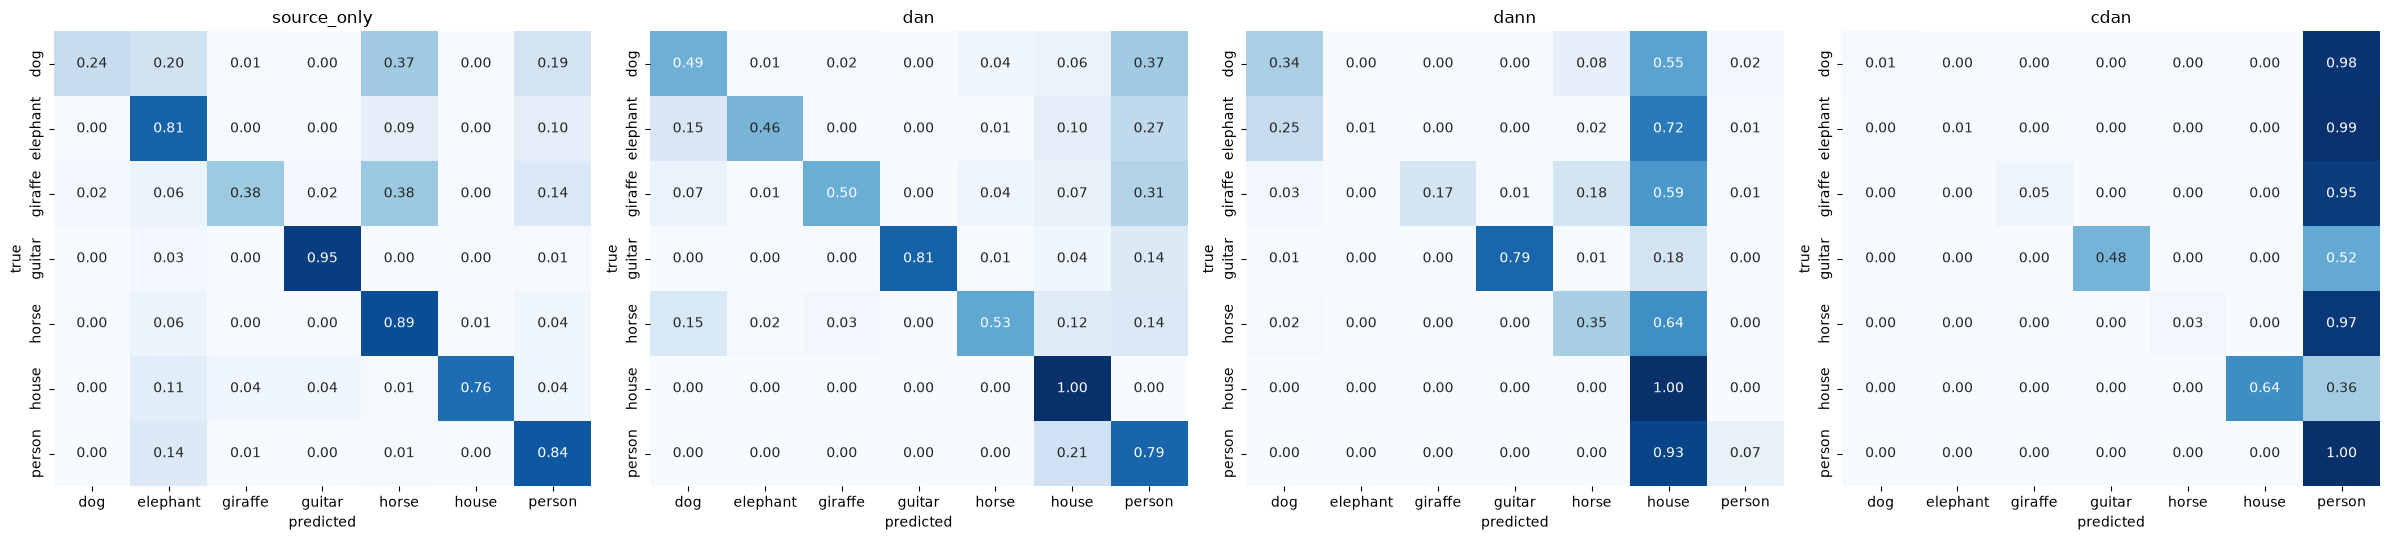

,method,true,predicted,images,share_of_true_class
0,source_only,giraffe,horse,287,38.11
1,source_only,dog,horse,286,37.05
2,source_only,dog,elephant,153,19.82
3,dan,dog,person,287,37.18
4,dan,giraffe,person,234,31.08
5,dan,elephant,person,199,26.89
6,dann,elephant,house,530,71.62
7,dann,horse,house,519,63.60
8,dann,giraffe,house,448,59.50
9,cdan,horse,person,790,96.81


In [22]:
#row normalised cuz classes range 80 to 816
fig, axes = plt.subplots(1, len(main_runs), figsize=(24, 5.5))
confusion_rows = []

for axis, run_name in zip(axes, main_runs):
    labels = evaluation[run_name]['target_labels']
    predictions = evaluation[run_name]['target_predictions']
    counts = confusion_matrix(labels, predictions, labels=list(range(NUM_CLASSES)))
    row_normalised = counts / counts.sum(axis=1, keepdims=True)

    sns.heatmap(row_normalised, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axis)
    axis.set_title(run_name)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')

    off_diagonal = counts.copy() #top 3 off diagonal confusions
    np.fill_diagonal(off_diagonal, 0)
    for flat_index in np.argsort(off_diagonal.ravel())[::-1][:3]:
        true_class, predicted_class = np.unravel_index(flat_index, off_diagonal.shape)
        confusion_rows.append({'method': run_name, 'true': CLASS_NAMES[true_class], 'predicted': CLASS_NAMES[predicted_class],
                               'images': int(off_diagonal[true_class, predicted_class]),
                               'share_of_true_class': 100 * row_normalised[true_class, predicted_class]})

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

dominant_confusions = pd.DataFrame(confusion_rows)
dominant_confusions.to_csv(OUTPUT_DIR / 'dominant_confusions.csv', index=False)
display(dominant_confusions.round(2))

dan   lost 842 images that source only had right, gained 517
dann  lost 1491 images that source only had right, gained 180
cdan  lost 2022 images that source only had right, gained 34


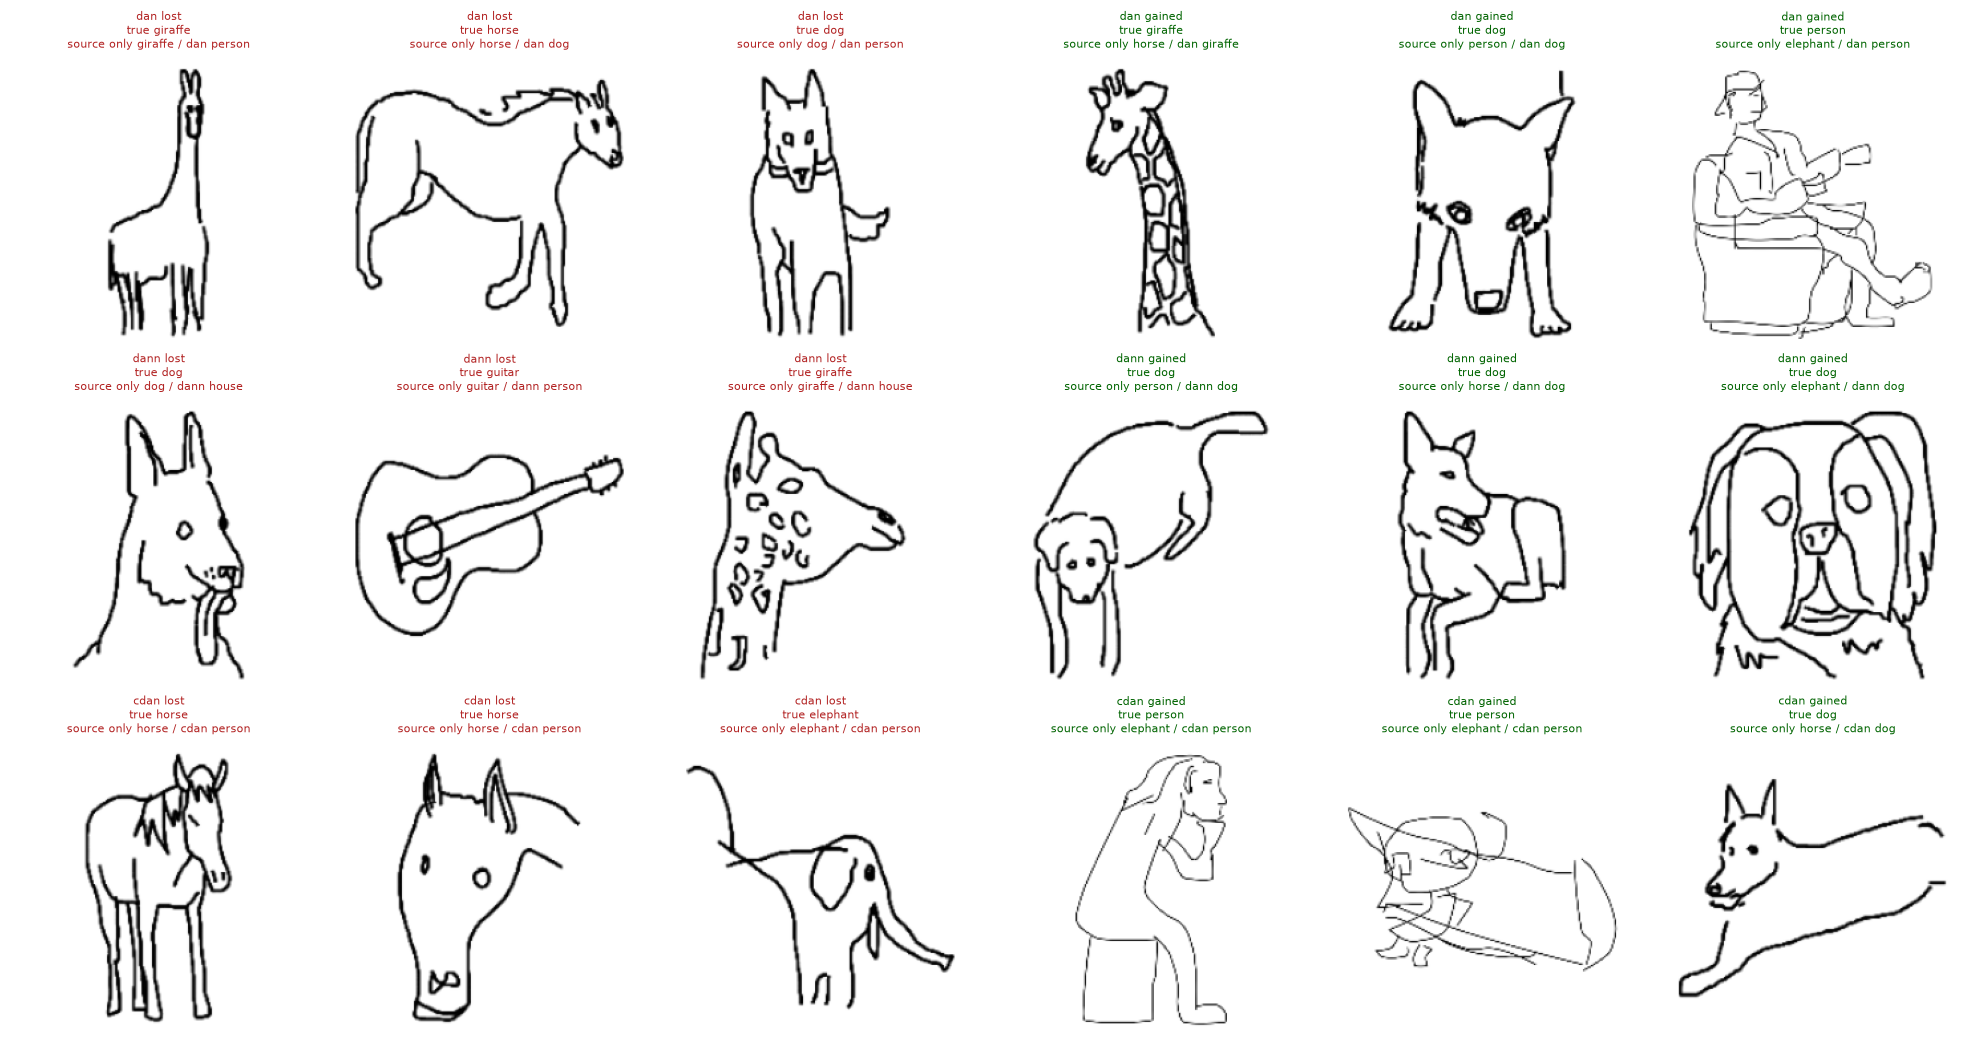

In [23]:
#lost/gained sketches per method, seeded shuffle so no cherry picking
display_transform = transforms.Compose([transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)), transforms.CenterCrop(CROP_SIZE)])
source_only_predictions = evaluation['source_only']['target_predictions']
target_labels = evaluation['source_only']['target_labels'] #same for every run, loader isnt shuffled

examples_per_side = 3
fig, axes = plt.subplots(3, 2 * examples_per_side, figsize=(20, 10.5))

for row, run_name in enumerate(['dan', 'dann', 'cdan']):
    method_predictions = evaluation[run_name]['target_predictions']
    lost = np.flatnonzero((source_only_predictions == target_labels) & (method_predictions != target_labels))
    gained = np.flatnonzero((source_only_predictions != target_labels) & (method_predictions == target_labels))
    shuffle = np.random.default_rng(SEED)

    chosen = [('lost', position) for position in shuffle.permutation(lost)[:examples_per_side]]
    chosen += [('gained', position) for position in shuffle.permutation(gained)[:examples_per_side]]

    for column in range(2 * examples_per_side):
        axis = axes[row, column]
        axis.axis('off')
        if column >= len(chosen):
            continue
        kind, position = chosen[column]
        image = display_transform(Image.open(io.BytesIO(image_bytes[target_rows[position]])).convert('RGB'))
        axis.imshow(image)
        axis.set_title(f'{run_name} {kind}\ntrue {CLASS_NAMES[target_labels[position]]}\n'
                       f'source only {CLASS_NAMES[source_only_predictions[position]]} / {run_name} {CLASS_NAMES[method_predictions[position]]}',
                       fontsize=8, color='firebrick' if kind == 'lost' else 'darkgreen')

    print(f'{run_name:5s} lost {len(lost)} images that source only had right, gained {len(gained)}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'transfer_cases.png', dpi=180, bbox_inches='tight')
plt.show()

,mmd_weight,run,mean_source_accuracy,mean_source_macro_f1,domain_separability,target_accuracy,target_macro_f1,target_accuracy_change,selected_by_source_validation
0,0.1,dan_mmd_0.1,92.57,92.91,98.76,75.49,71.75,10.31,False
1,1.0,dan,93.21,92.93,84.34,56.91,55.31,-8.27,True
2,10.0,dan_mmd_10,87.93,87.82,85.03,68.44,67.28,3.26,False


,domain_loss_weight,run,mean_source_accuracy,mean_source_macro_f1,domain_separability,target_accuracy,target_macro_f1,max_classification_loss,max_feature_norm,epochs_trained,target_accuracy_change
0,0.1,dann_domain_0.1,93.55,93.77,99.73,67.80,69.90,0.55,77.48,10,2.62
1,1.0,dann,92.14,92.13,99.86,31.81,31.52,0.55,108.08,9,-33.37


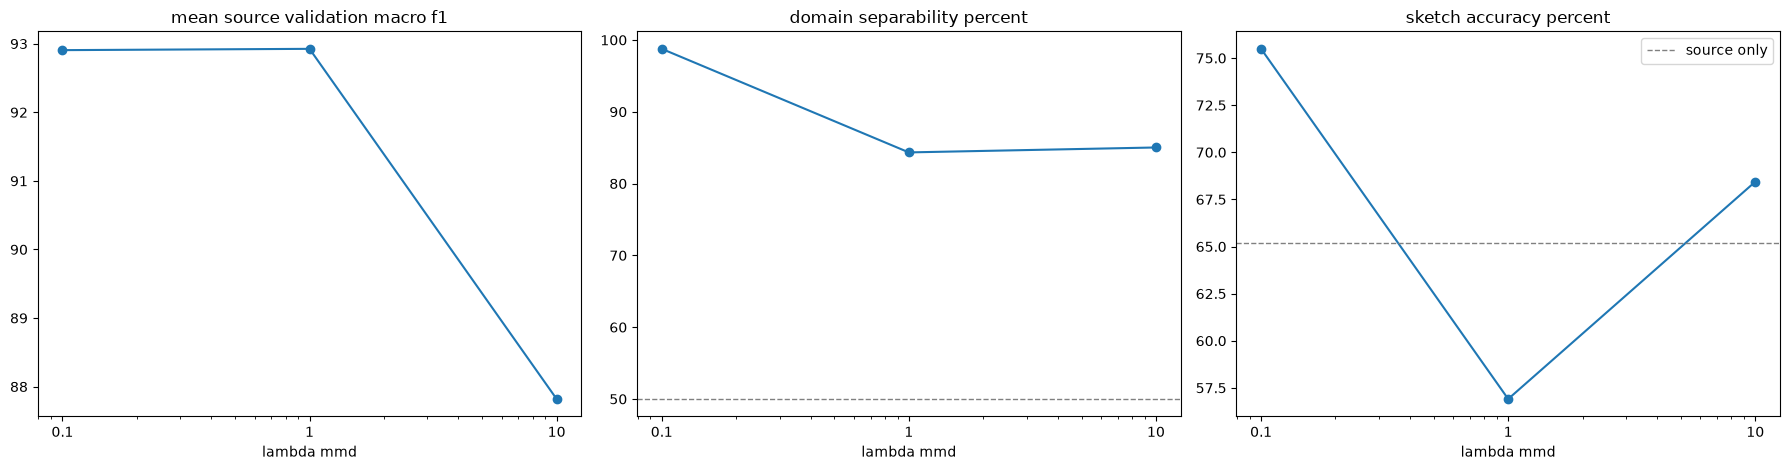

In [24]:
#selected_by_source_validation = what our rule picks without target labels
design_rows = []
for mmd_weight, run_name in design_study_runs.items():
    design_rows.append({
        'mmd_weight': mmd_weight,
        'run': run_name,
        'mean_source_accuracy': evaluation[run_name]['mean_source_accuracy'],
        'mean_source_macro_f1': evaluation[run_name]['mean_source_macro_f1'],
        'domain_separability': evaluation[run_name]['domain_separability'],
        'target_accuracy': evaluation[run_name]['target_accuracy'],
        'target_macro_f1': evaluation[run_name]['target_macro_f1'],
    })

design_study = pd.DataFrame(design_rows)
design_study['target_accuracy_change'] = design_study['target_accuracy'] - evaluation['source_only']['target_accuracy']
design_study['selected_by_source_validation'] = design_study['mean_source_macro_f1'] == design_study['mean_source_macro_f1'].max()
design_study.to_csv(OUTPUT_DIR / 'design_study_mmd_weight.csv', index=False)
display(design_study.round(2))

domain_rows = []
for domain_weight, run_name in domain_weight_runs.items():
    domain_rows.append({
        'domain_loss_weight': domain_weight,
        'run': run_name,
        'mean_source_accuracy': evaluation[run_name]['mean_source_accuracy'],
        'mean_source_macro_f1': evaluation[run_name]['mean_source_macro_f1'],
        'domain_separability': evaluation[run_name]['domain_separability'],
        'target_accuracy': evaluation[run_name]['target_accuracy'],
        'target_macro_f1': evaluation[run_name]['target_macro_f1'],
        'max_classification_loss': histories[run_name]['classification_loss'].max(),
        'max_feature_norm': histories[run_name]['feature_norm_mean'].max(),
        'epochs_trained': len(histories[run_name]),
    })

domain_weight_study = pd.DataFrame(domain_rows)
domain_weight_study['target_accuracy_change'] = domain_weight_study['target_accuracy'] - evaluation['source_only']['target_accuracy']
domain_weight_study.to_csv(OUTPUT_DIR / 'design_study_domain_weight.csv', index=False)
display(domain_weight_study.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
panels = [
    ('mean_source_macro_f1', 'mean source validation macro f1'),
    ('domain_separability', 'domain separability percent'),
    ('target_accuracy', 'sketch accuracy percent'),
]
for axis, (column, title) in zip(axes, panels):
    axis.plot(design_study['mmd_weight'], design_study[column], marker='o')
    axis.set_xscale('log')
    axis.set_xticks(DESIGN_STUDY_MMD_WEIGHTS)
    axis.set_xticklabels([f'{weight:g}' for weight in DESIGN_STUDY_MMD_WEIGHTS])
    axis.set_xlabel('lambda mmd')
    axis.set_title(title)
axes[1].axhline(50, color='grey', linestyle='--', linewidth=1)
axes[2].axhline(evaluation['source_only']['target_accuracy'], color='grey', linestyle='--', linewidth=1, label='source only')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'design_study_mmd_weight.png', dpi=180, bbox_inches='tight')
plt.show()

for run_name in models:
    models[run_name] = models[run_name].cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()